In [ ]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd # <-- Aggiunto pandas per eventuale pulizia
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import utils

# Importiamo i nostri moduli rifattorizzati!
from dataset import load_raw_data, encode_labels, get_holdout_dataloaders, create_dataloader
from models import MLP
from losses import PolyLoss, CombinedCLoss
from engine import train_model, evaluate_model
from plot_utils import plot_training_history
from gdv_utils import calculate_gdv

# ==========================================
# CABINA DI REGIA: SCELTA DEL DATASET
# ==========================================
# 59 = Letter Recognition | 222 = Bank Marketing | 572 = Taiwanese Bankruptcy
DATASET_ID = 59 
DATASET_NAME = "Letter Recognition"
DATASET_NAME_SAFE = DATASET_NAME.replace(" ", "_").replace("/", "-")

# Seed e Device
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo in uso: {device}")
print(f"=== INIZIALIZZAZIONE PIPELINE: {DATASET_NAME} (ID: {DATASET_ID}) ===\n")

# 1. Caricamento e preparazione dati
X_raw, y_raw_text = load_raw_data(dataset_id=DATASET_ID)

# ---------------------------------------------------------
# ATTENZIONE: GESTIONE VARIABILI CATEGORICHE (Es. Bank Marketing)
# ---------------------------------------------------------
# Letter Recognition aveva solo numeri, ma Bank Marketing ha colonne testuali 
# (es. "job"="admin", "marital"="married"). Lo StandardScaler andrebbe in crash!
# Usiamo pd.get_dummies() per trasformare il testo in numeri (One-Hot Encoding)
if isinstance(X_raw, np.ndarray):
    X_raw_df = pd.DataFrame(X_raw)
else:
    X_raw_df = X_raw.copy()

# Trasforma le colonne testuali in colonne numeriche binarie (es. job_admin: 1 o 0)
X_raw_numeric = pd.get_dummies(X_raw_df, drop_first=True).values.astype(np.float32)

y_raw, num_classes = encode_labels(y_raw_text)

# Estrarre dinamicamente l'input_dim per passare al modello successivamente!
input_dim = X_raw_numeric.shape[1]
print(f"Numero di campioni: {X_raw_numeric.shape[0]}")
print(f"Numero di feature in input: {input_dim}")
print(f"Numero di classi in output: {num_classes}\n")

# 2. Creazione Dataloader per gli esperimenti Hold-Out
# N.B. Passiamo X_raw_numeric (già convertito in numeri) anziché X_raw
train_loader, val_loader, test_loader = get_holdout_dataloaders(X_raw_numeric, y_raw, batch_size=64)

Dispositivo in uso: cuda

Scaricamento del dataset Letter Recognition (UCI ID 59)...


In [3]:
# ==========================================
# CONFIGURAZIONE DINAMICA DEL DATASET
# ==========================================
# Modifica queste variabili quando passi a un nuovo dataset
DATASET_NAME = "Letter Recognition"
DATASET_ID = 59 

# Creiamo una versione "sicura" del nome da usare nei file (senza spazi)
DATASET_NAME_SAFE = DATASET_NAME.replace(" ", "_").replace("/", "-")

print(f"=== INIZIALIZZAZIONE PIPELINE: {DATASET_NAME} ===")

# Per valutare il GDV di partenza, scaliamo l'intero dataset. 
# NOTA: Questo scaling serve SOLO per la valutazione geometrica iniziale, non per il training!
X_scaled_baseline = StandardScaler().fit_transform(X_raw)

X_tensor = torch.tensor(X_scaled_baseline, dtype=torch.float32)
y_tensor = torch.tensor(y_raw, dtype=torch.long)

GDV_INIZIALE = calculate_gdv(X_tensor, y_tensor)

print(f"Dataset ID: {DATASET_ID}")
print(f"GDV Dati Grezzi: {GDV_INIZIALE:.4f}")
print("===================================================")

=== INIZIALIZZAZIONE PIPELINE: Letter Recognition ===
Dataset ID: 59
GDV Dati Grezzi: -0.1464



Avvio Addestramento: Cross-Entropy su Letter Recognition (Hold-Out)
Epoca 01/30 | Train Loss: 1.8585 | Val Loss: 1.0418 | Val Acc: 71.39% | Val GDV: -0.2541
Epoca 05/30 | Train Loss: 0.4988 | Val Loss: 0.4871 | Val Acc: 85.66% | Val GDV: -0.2559
Epoca 10/30 | Train Loss: 0.2840 | Val Loss: 0.3073 | Val Acc: 90.64% | Val GDV: -0.2534
Epoca 15/30 | Train Loss: 0.1882 | Val Loss: 0.2317 | Val Acc: 93.01% | Val GDV: -0.2497
Epoca 20/30 | Train Loss: 0.1349 | Val Loss: 0.1880 | Val Acc: 94.05% | Val GDV: -0.2464
Epoca 25/30 | Train Loss: 0.1026 | Val Loss: 0.1676 | Val Acc: 94.55% | Val GDV: -0.2433
Epoca 30/30 | Train Loss: 0.0813 | Val Loss: 0.1556 | Val Acc: 94.69% | Val GDV: -0.2409

> Training completato in 14.72s.
> Ripristino pesi dell'epoca 30 (Miglior Val Loss: 0.1556)
Accuratezza Test Finale: 95.03%
[*] Storico salvato in: logs\2026-05-04_19-50-36-HoldOut_CE_Letter_Recognition.json
[*] Grafico salvato: plots\2026-05-04_19-50-36_Cross-Entropy_(Letter_Recognition)_Loss.pdf


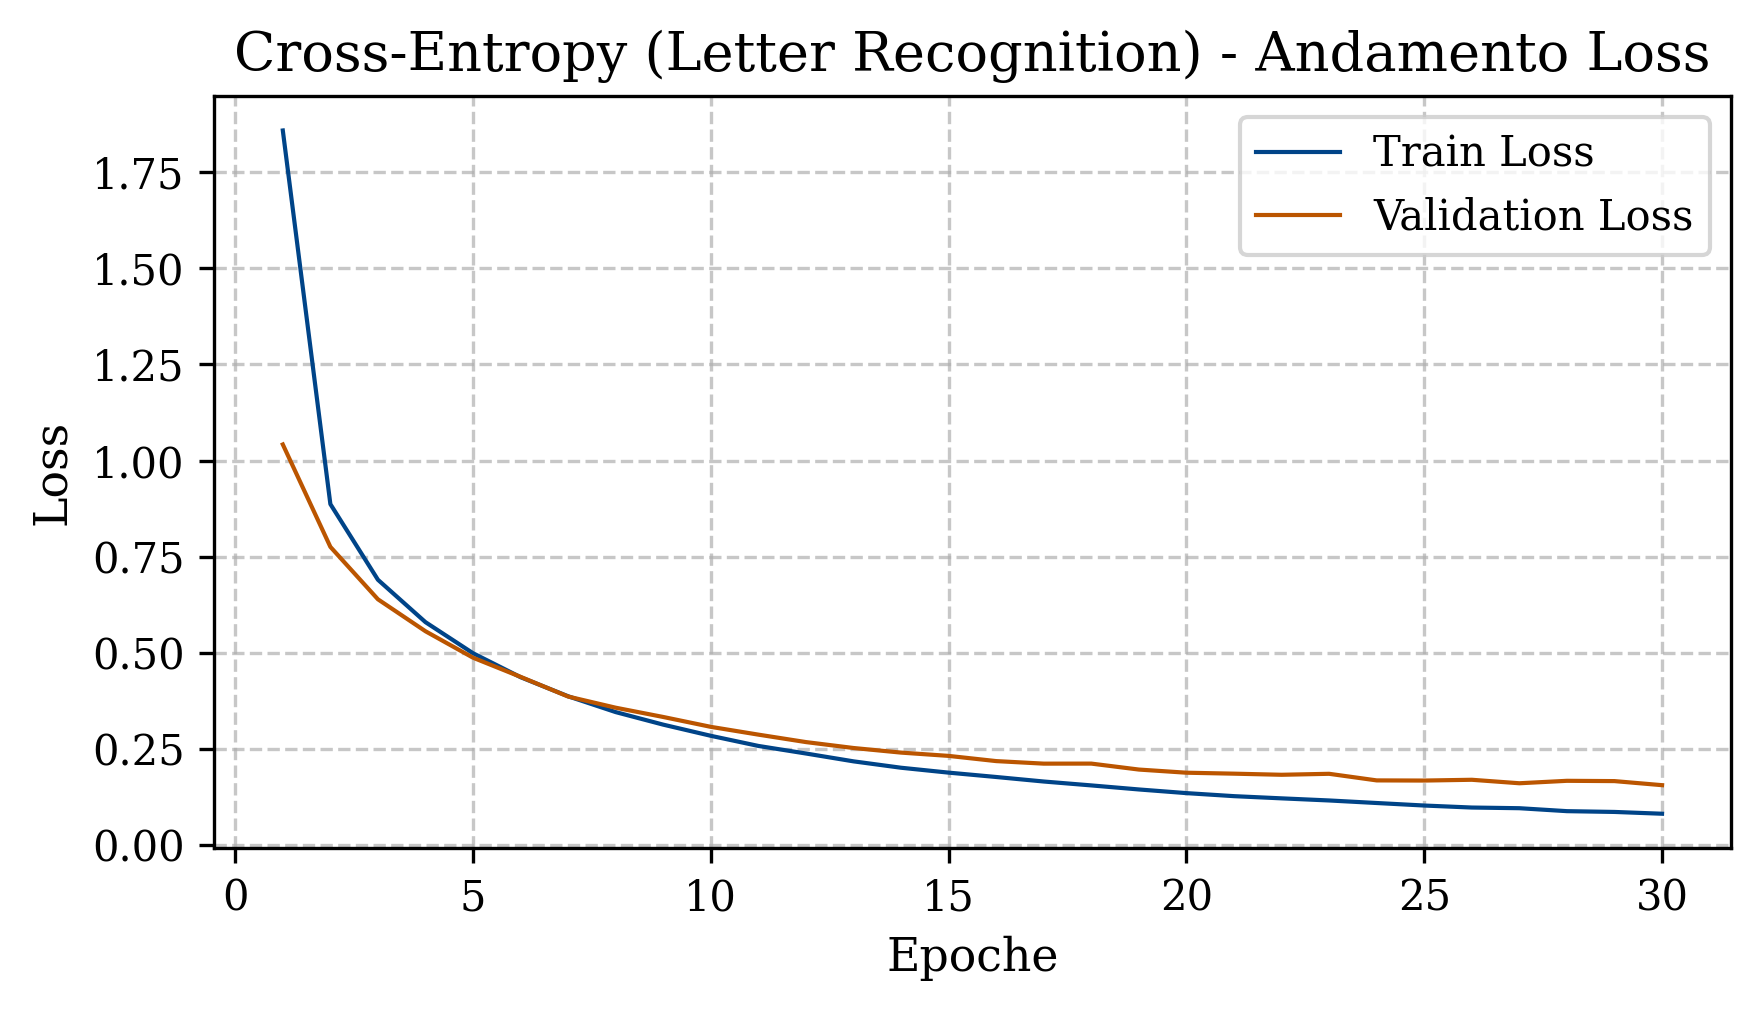

[*] Grafico salvato: plots\2026-05-04_19-50-36_Cross-Entropy_(Letter_Recognition)_Accuracy.pdf


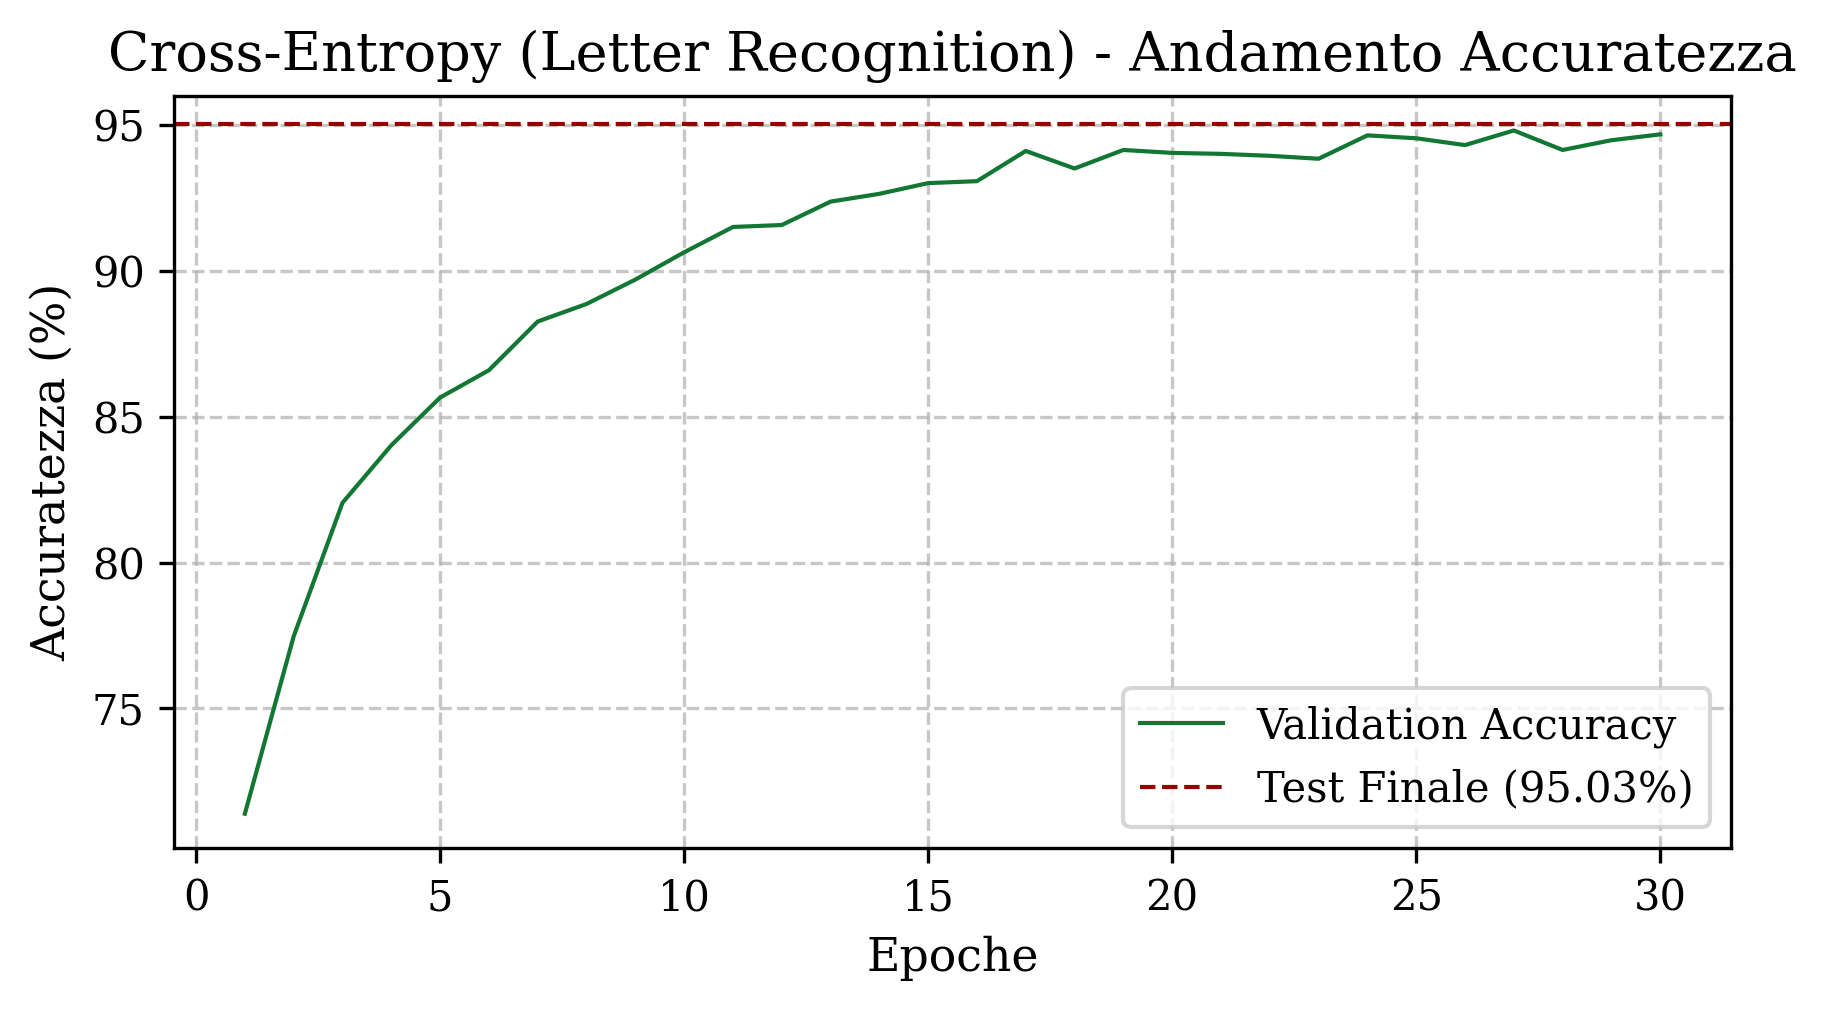

[*] Grafico salvato: plots\2026-05-04_19-50-36_Cross-Entropy_(Letter_Recognition)_GDV.pdf


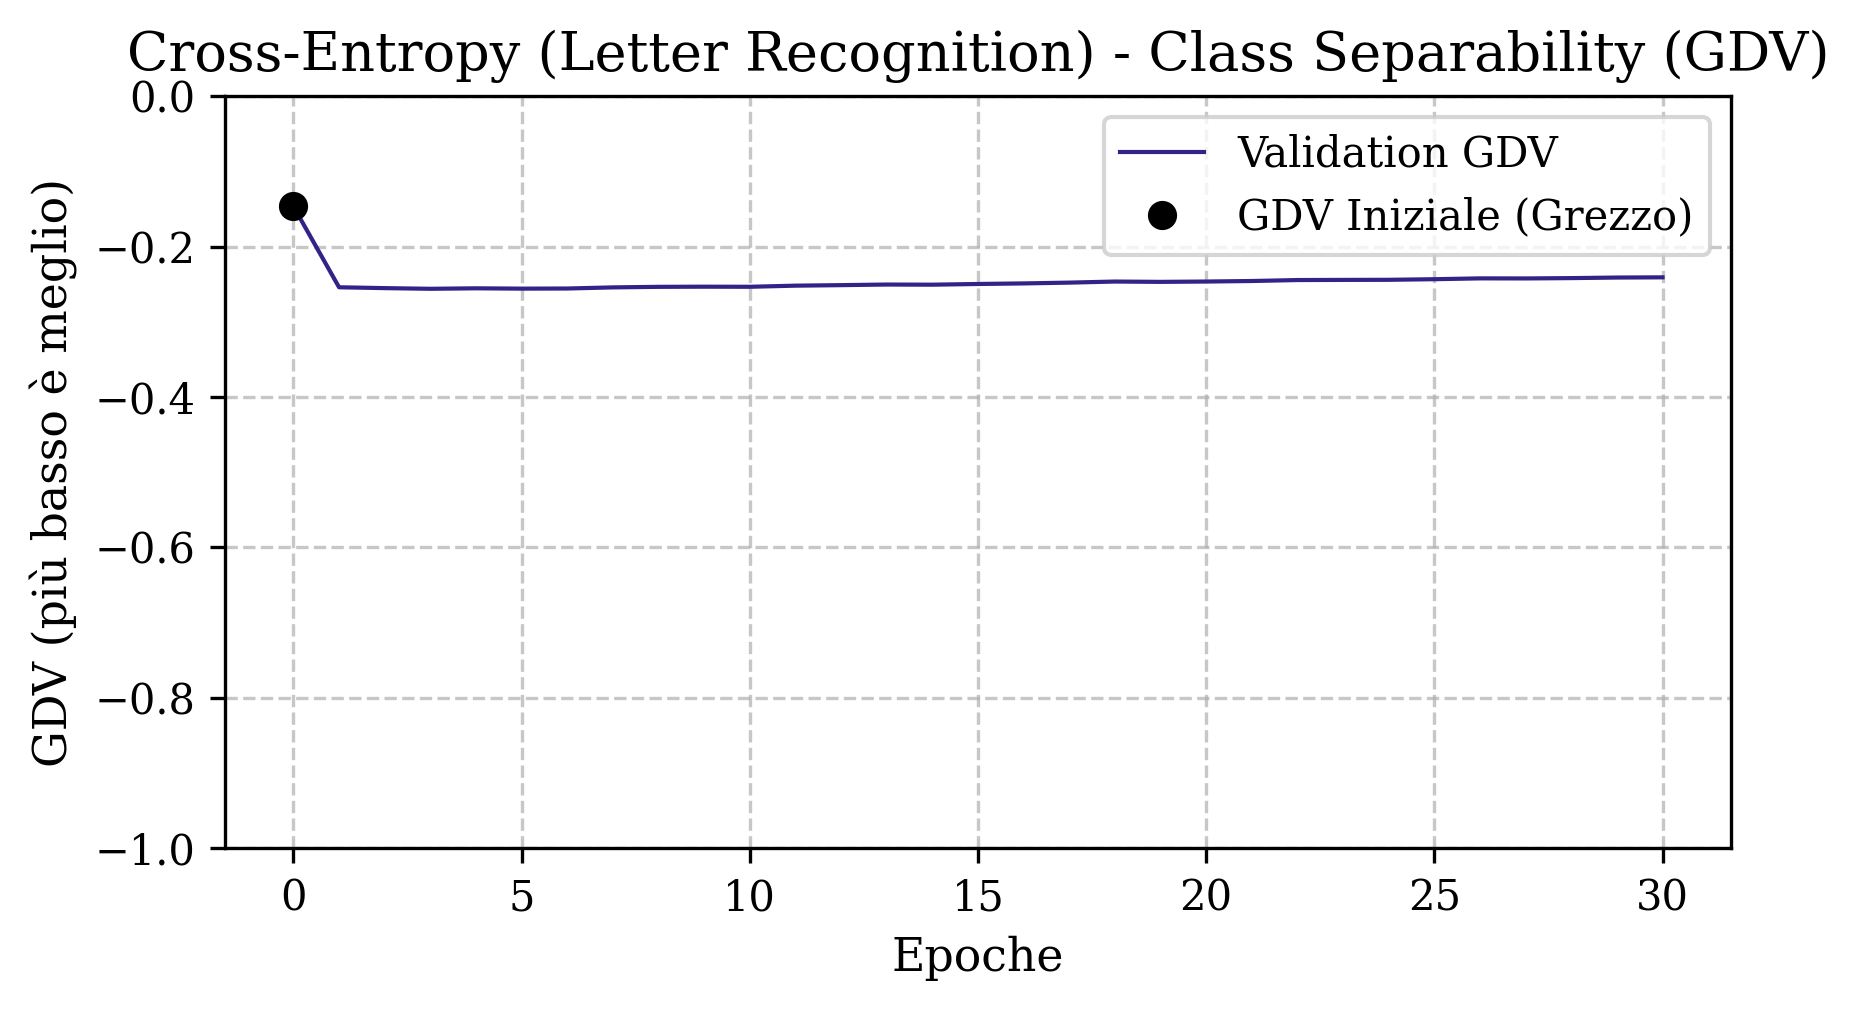

In [ ]:
# === ESPERIMENTO 1: BASELINE (CROSS-ENTROPY) ===
print(f"\nAvvio Addestramento: Cross-Entropy su {DATASET_NAME} (Hold-Out)")

torch.manual_seed(42)
input_dim = X_tensor.shape[1] 
model_ce = MLP(input_size=input_dim, num_classes=num_classes).to(device)
criterion_ce = nn.CrossEntropyLoss()
optimizer_ce = optim.Adam(model_ce.parameters(), lr=0.001)

history_ce, best_epoch_ce = train_model(
    model=model_ce, criterion=criterion_ce, optimizer=optimizer_ce, 
    train_loader=train_loader, val_loader=val_loader, device=device,
    num_epochs=500, layer_for_gdv=model_ce.relu2
)

test_acc_ce = evaluate_model(model_ce, test_loader, device)
history_ce['test_acc'] = test_acc_ce
print(f"Accuratezza Test Finale: {test_acc_ce:.2f}%")

# MLOps: Salvataggio log in JSON e generazione Grafici PDF
utils.salva_storico_json(history_ce, f"HoldOut_CE_{DATASET_NAME_SAFE}", directory="logs")
plot_training_history(history_ce, f"Cross-Entropy ({DATASET_NAME})", GDV_INIZIALE, save_dir="plots")


Avvio Addestramento: PolyLoss su Letter Recognition (Hold-Out)
Epoca 01/30 | Train Loss: 3.2390 | Val Loss: 1.9226 | Val Acc: 70.15% | Val GDV: -0.2530
Epoca 05/30 | Train Loss: 0.9563 | Val Loss: 0.9327 | Val Acc: 85.76% | Val GDV: -0.2545
Epoca 10/30 | Train Loss: 0.5718 | Val Loss: 0.6115 | Val Acc: 90.21% | Val GDV: -0.2520
Epoca 15/30 | Train Loss: 0.3901 | Val Loss: 0.4677 | Val Acc: 92.81% | Val GDV: -0.2490
Epoca 20/30 | Train Loss: 0.2822 | Val Loss: 0.3748 | Val Acc: 94.32% | Val GDV: -0.2458
Epoca 25/30 | Train Loss: 0.2192 | Val Loss: 0.3187 | Val Acc: 94.72% | Val GDV: -0.2433
Epoca 30/30 | Train Loss: 0.1755 | Val Loss: 0.3021 | Val Acc: 94.69% | Val GDV: -0.2406

> Training completato in 16.76s.
> Ripristino pesi dell'epoca 30 (Miglior Val Loss: 0.3021)
Accuratezza Test Finale: 95.00%
[*] Storico salvato in: logs\2026-05-04_19-52-12-HoldOut_PolyLoss_Letter_Recognition.json
[*] Grafico salvato: plots\2026-05-04_19-52-12_PolyLoss_(Letter_Recognition)_Loss.pdf


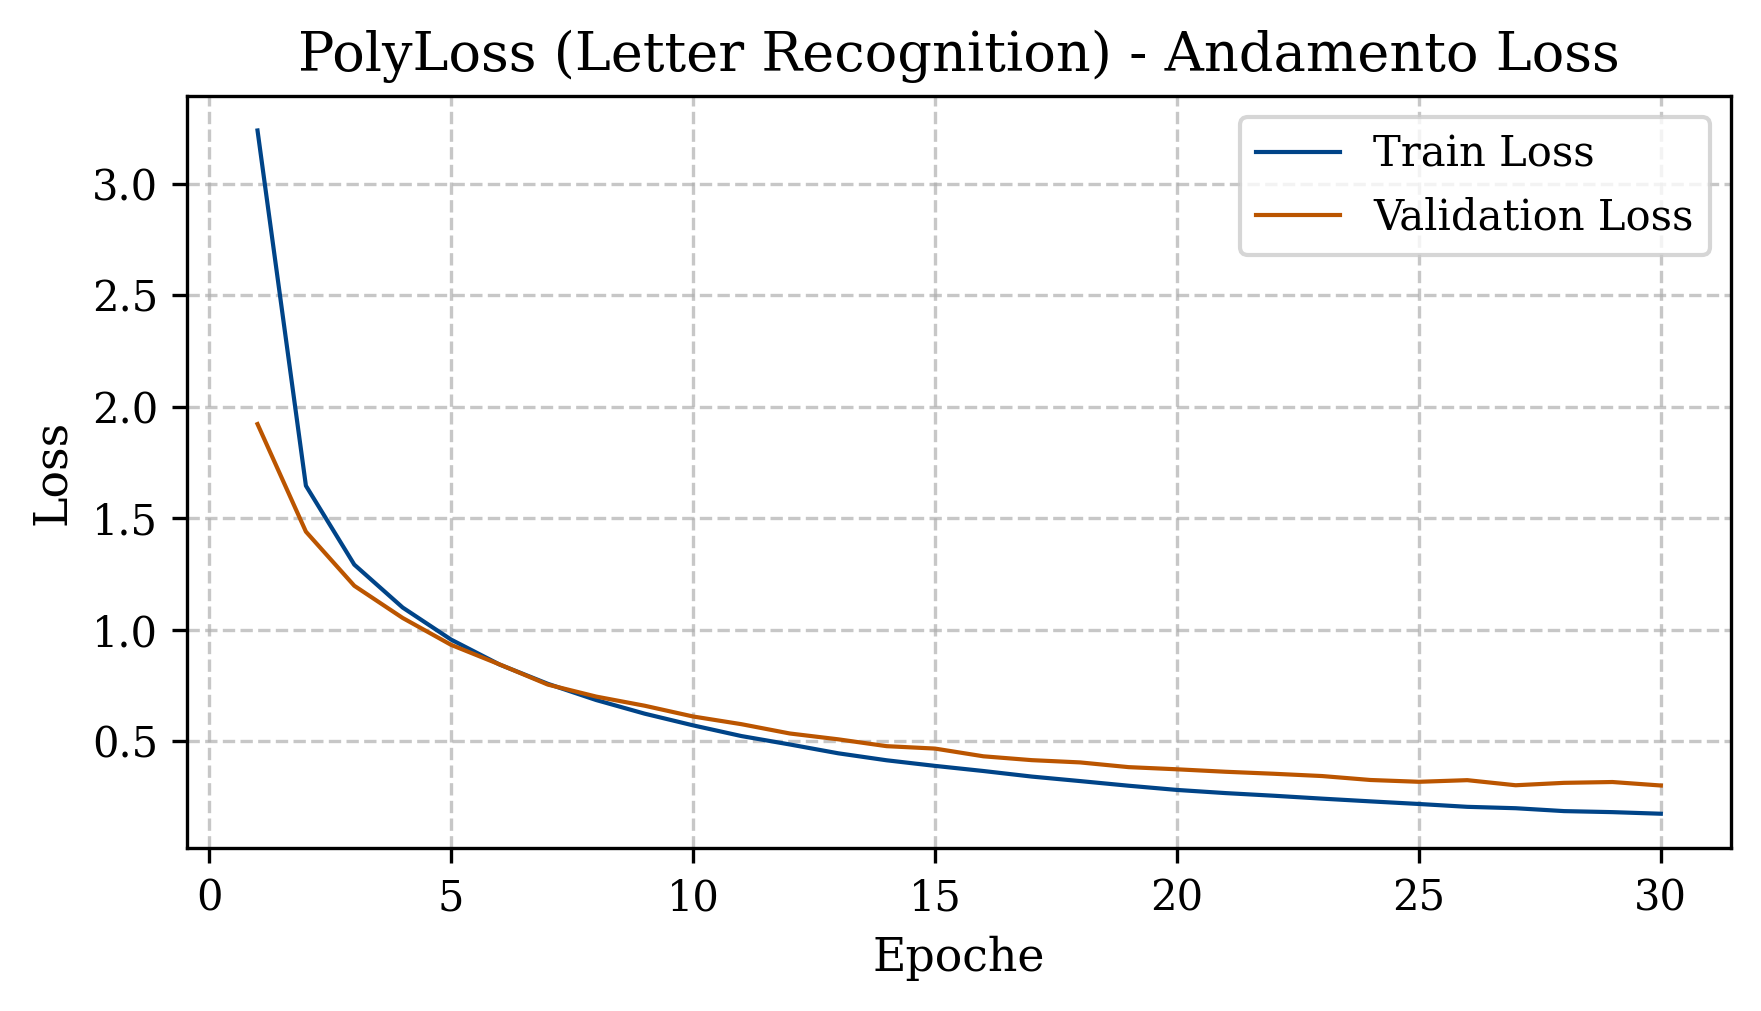

[*] Grafico salvato: plots\2026-05-04_19-52-12_PolyLoss_(Letter_Recognition)_Accuracy.pdf


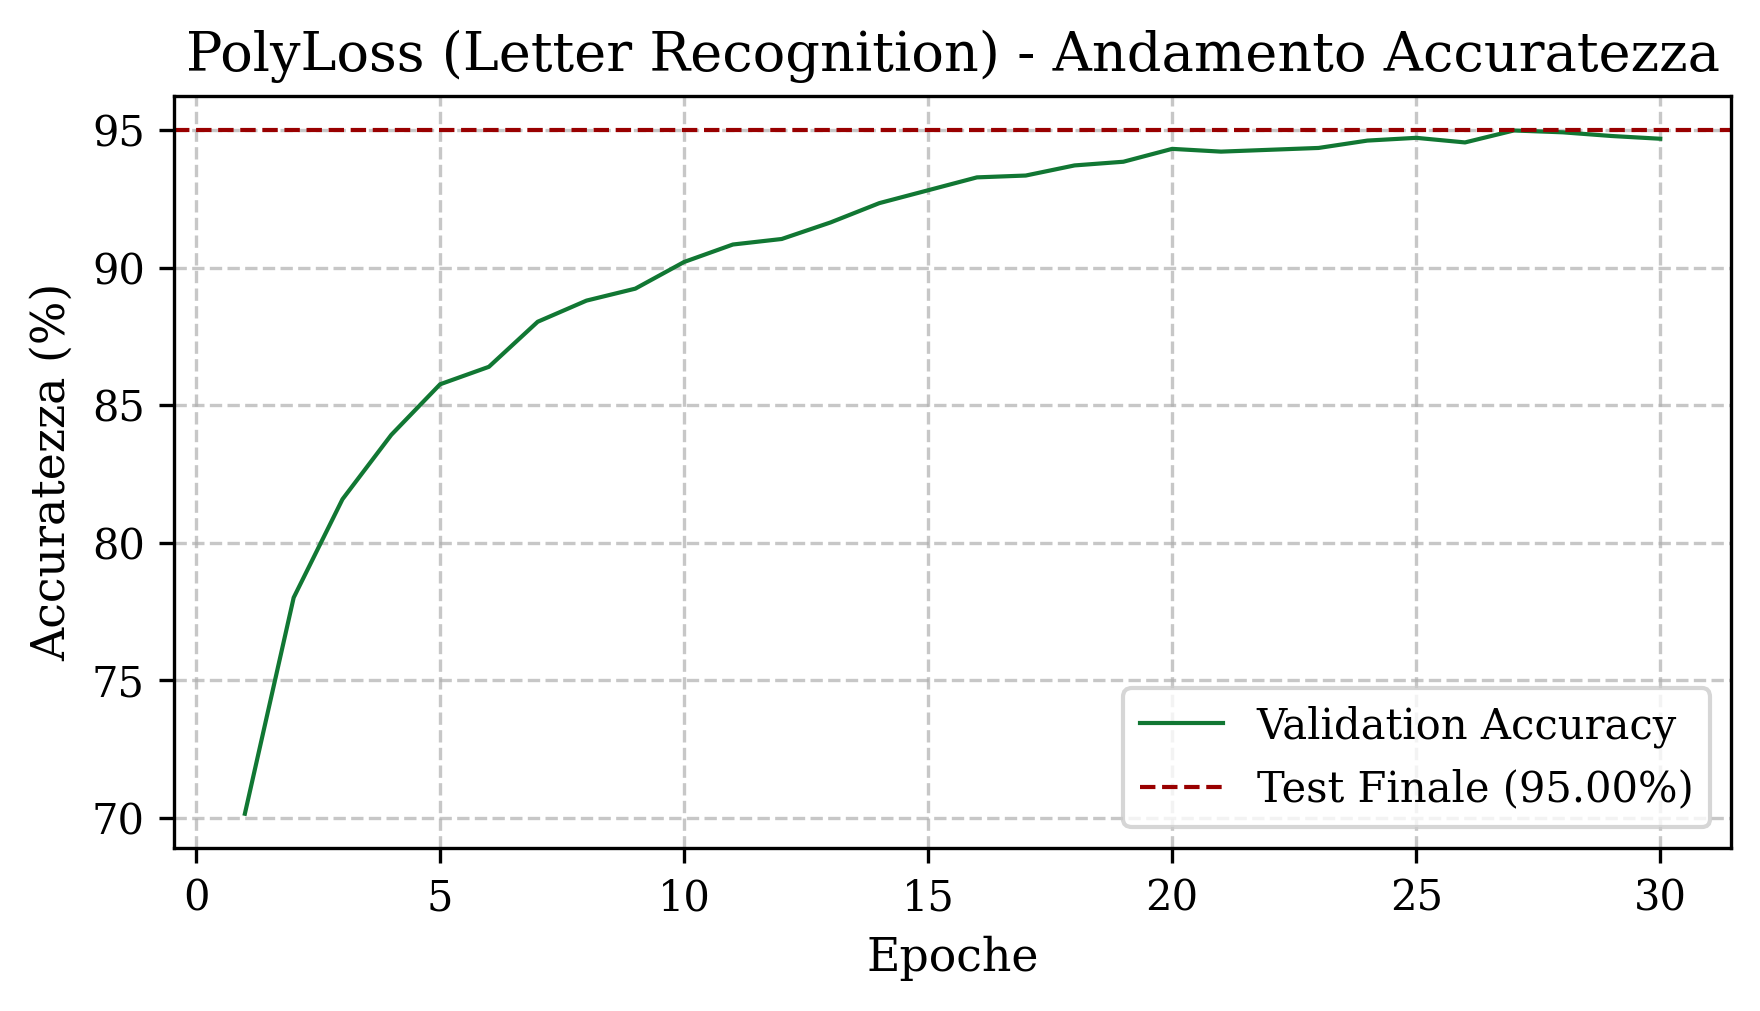

[*] Grafico salvato: plots\2026-05-04_19-52-12_PolyLoss_(Letter_Recognition)_GDV.pdf


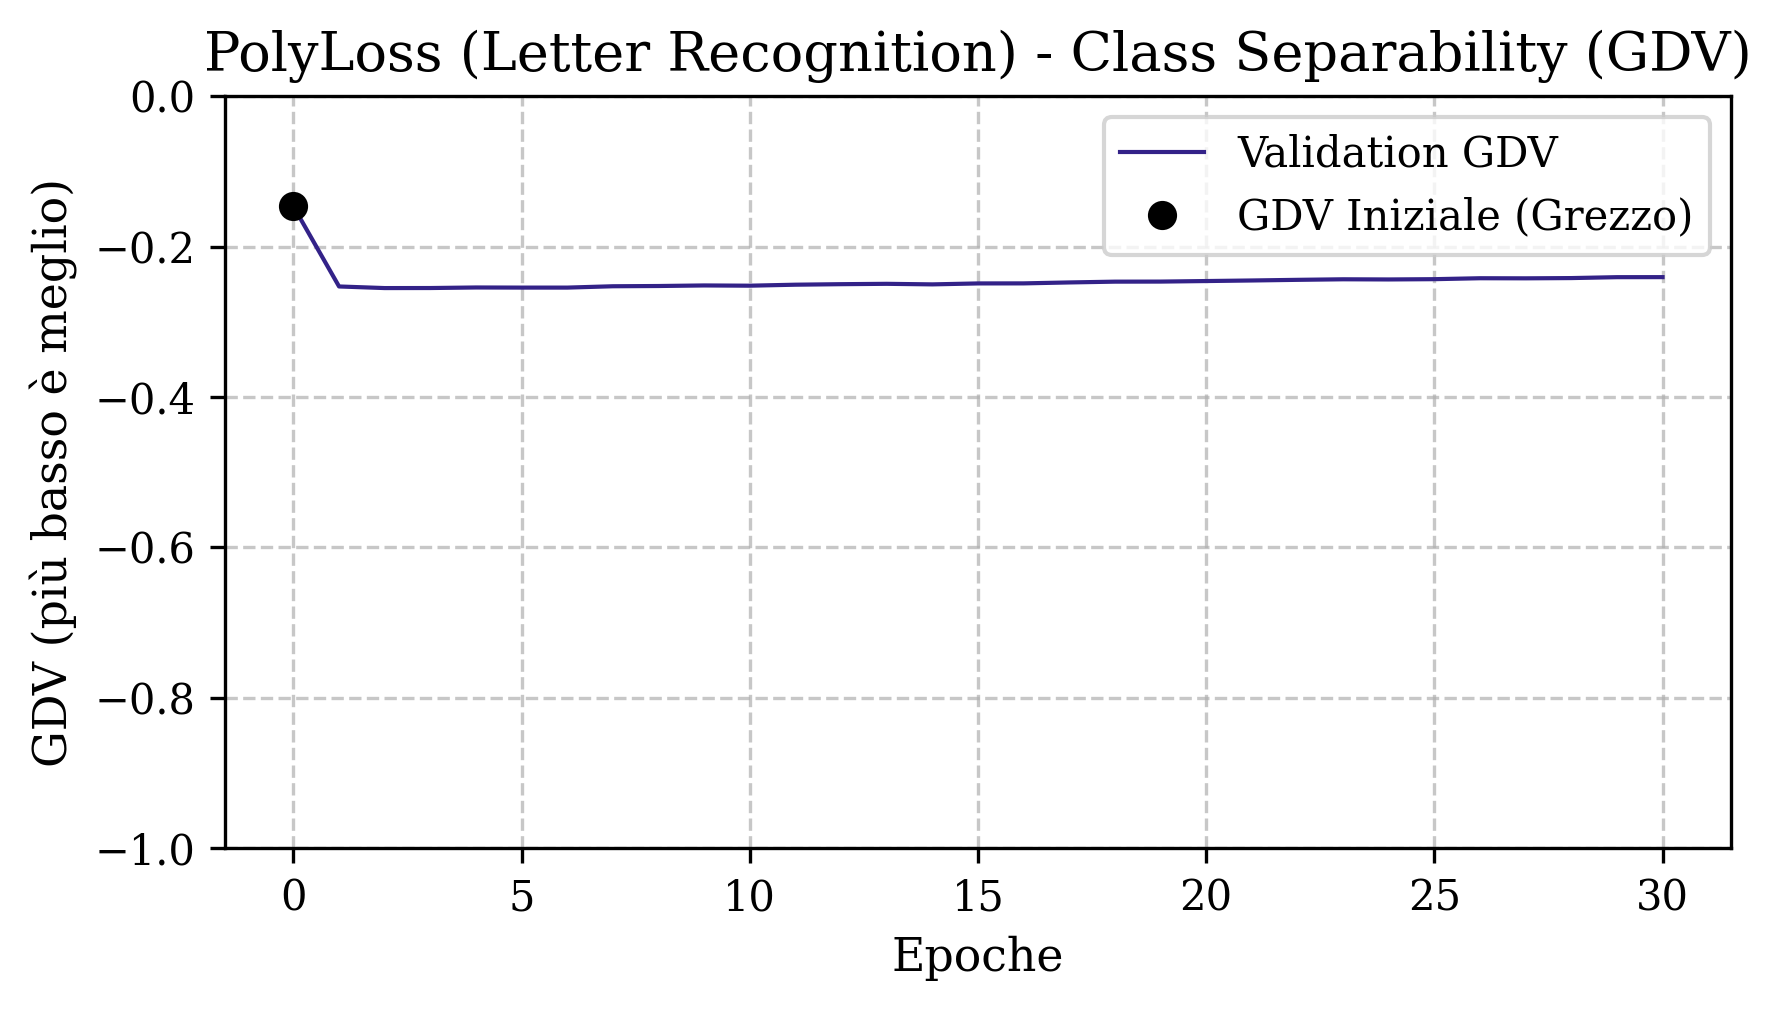

In [ ]:
# === ESPERIMENTO 2: POLYLOSS ===
print(f"\nAvvio Addestramento: PolyLoss su {DATASET_NAME} (Hold-Out)")

torch.manual_seed(42)
input_dim = X_tensor.shape[1] 
model_polyloss = MLP(input_size=input_dim, num_classes=num_classes).to(device)
criterion_polyloss = PolyLoss()
optimizer_polyloss = optim.Adam(model_polyloss.parameters(), lr=0.001)

history_poly, best_epoch_poly = train_model(
    model=model_polyloss, 
    criterion=criterion_polyloss, 
    optimizer=optimizer_polyloss, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    device=device,
    num_epochs=500, 
    layer_for_gdv=model_polyloss.relu2
)

test_acc_poly = evaluate_model(model_polyloss, test_loader, device)
history_poly['test_acc'] = test_acc_poly
print(f"Accuratezza Test Finale: {test_acc_poly:.2f}%")

# MLOps: Salvataggio log in JSON e generazione Grafici PDF
utils.salva_storico_json(history_poly, f"HoldOut_PolyLoss_{DATASET_NAME_SAFE}", directory="logs")
plot_training_history(history_poly, f"PolyLoss ({DATASET_NAME})", GDV_INIZIALE, save_dir="plots")


Avvio Addestramento: Combined C-Loss su Letter Recognition (Hold-Out)
Epoca 01/30 | Train Loss: 1.3124 | Val Loss: 0.7621 | Val Acc: 70.22% | Val GDV: -0.2528
Epoca 05/30 | Train Loss: 0.3722 | Val Loss: 0.3644 | Val Acc: 85.39% | Val GDV: -0.2558
Epoca 10/30 | Train Loss: 0.2169 | Val Loss: 0.2353 | Val Acc: 90.31% | Val GDV: -0.2532
Epoca 15/30 | Train Loss: 0.1465 | Val Loss: 0.1780 | Val Acc: 92.71% | Val GDV: -0.2498
Epoca 20/30 | Train Loss: 0.1049 | Val Loss: 0.1406 | Val Acc: 94.15% | Val GDV: -0.2465
Epoca 25/30 | Train Loss: 0.0815 | Val Loss: 0.1210 | Val Acc: 94.72% | Val GDV: -0.2439
Epoca 30/30 | Train Loss: 0.0654 | Val Loss: 0.1160 | Val Acc: 94.72% | Val GDV: -0.2411

> Training completato in 19.42s.
> Ripristino pesi dell'epoca 30 (Miglior Val Loss: 0.1160)
Accuratezza Test Finale: 94.87%
[*] Storico salvato in: logs\2026-05-04_19-53-30-HoldOut_CombinedLoss_Letter_Recognition.json
[*] Grafico salvato: plots\2026-05-04_19-53-30_Combined_C-Loss_(Letter_Recognition)_Los

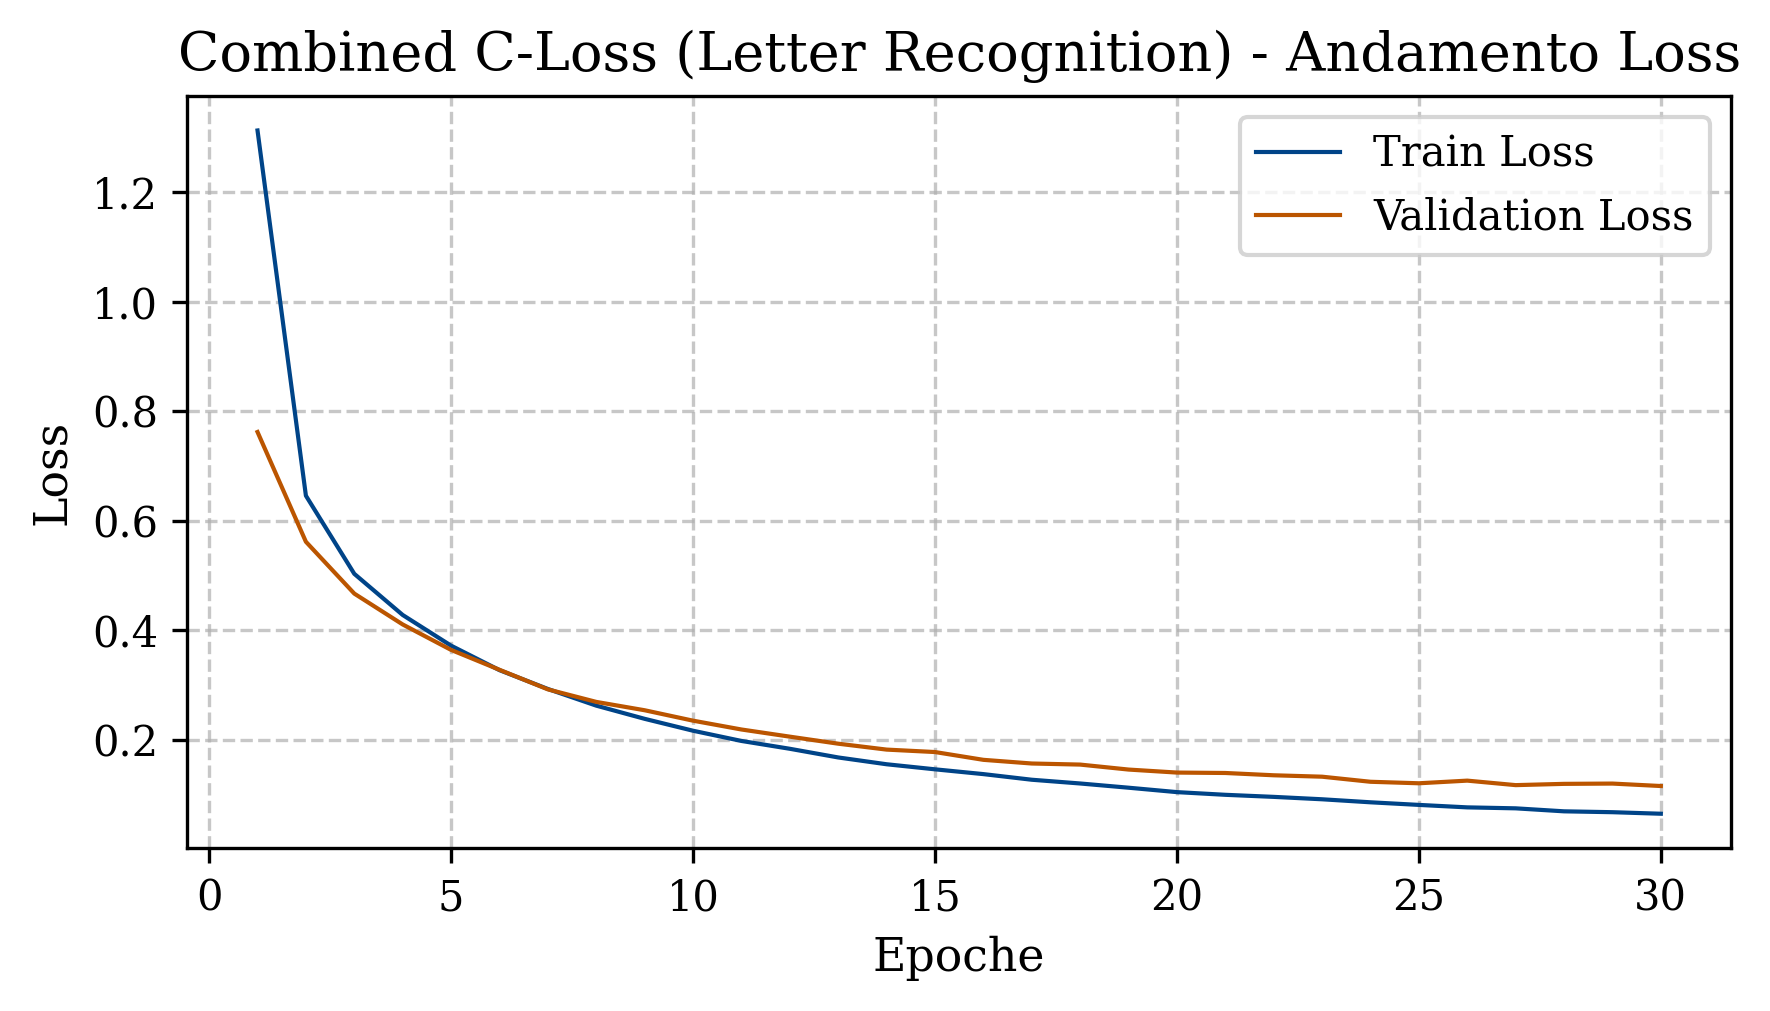

[*] Grafico salvato: plots\2026-05-04_19-53-30_Combined_C-Loss_(Letter_Recognition)_Accuracy.pdf


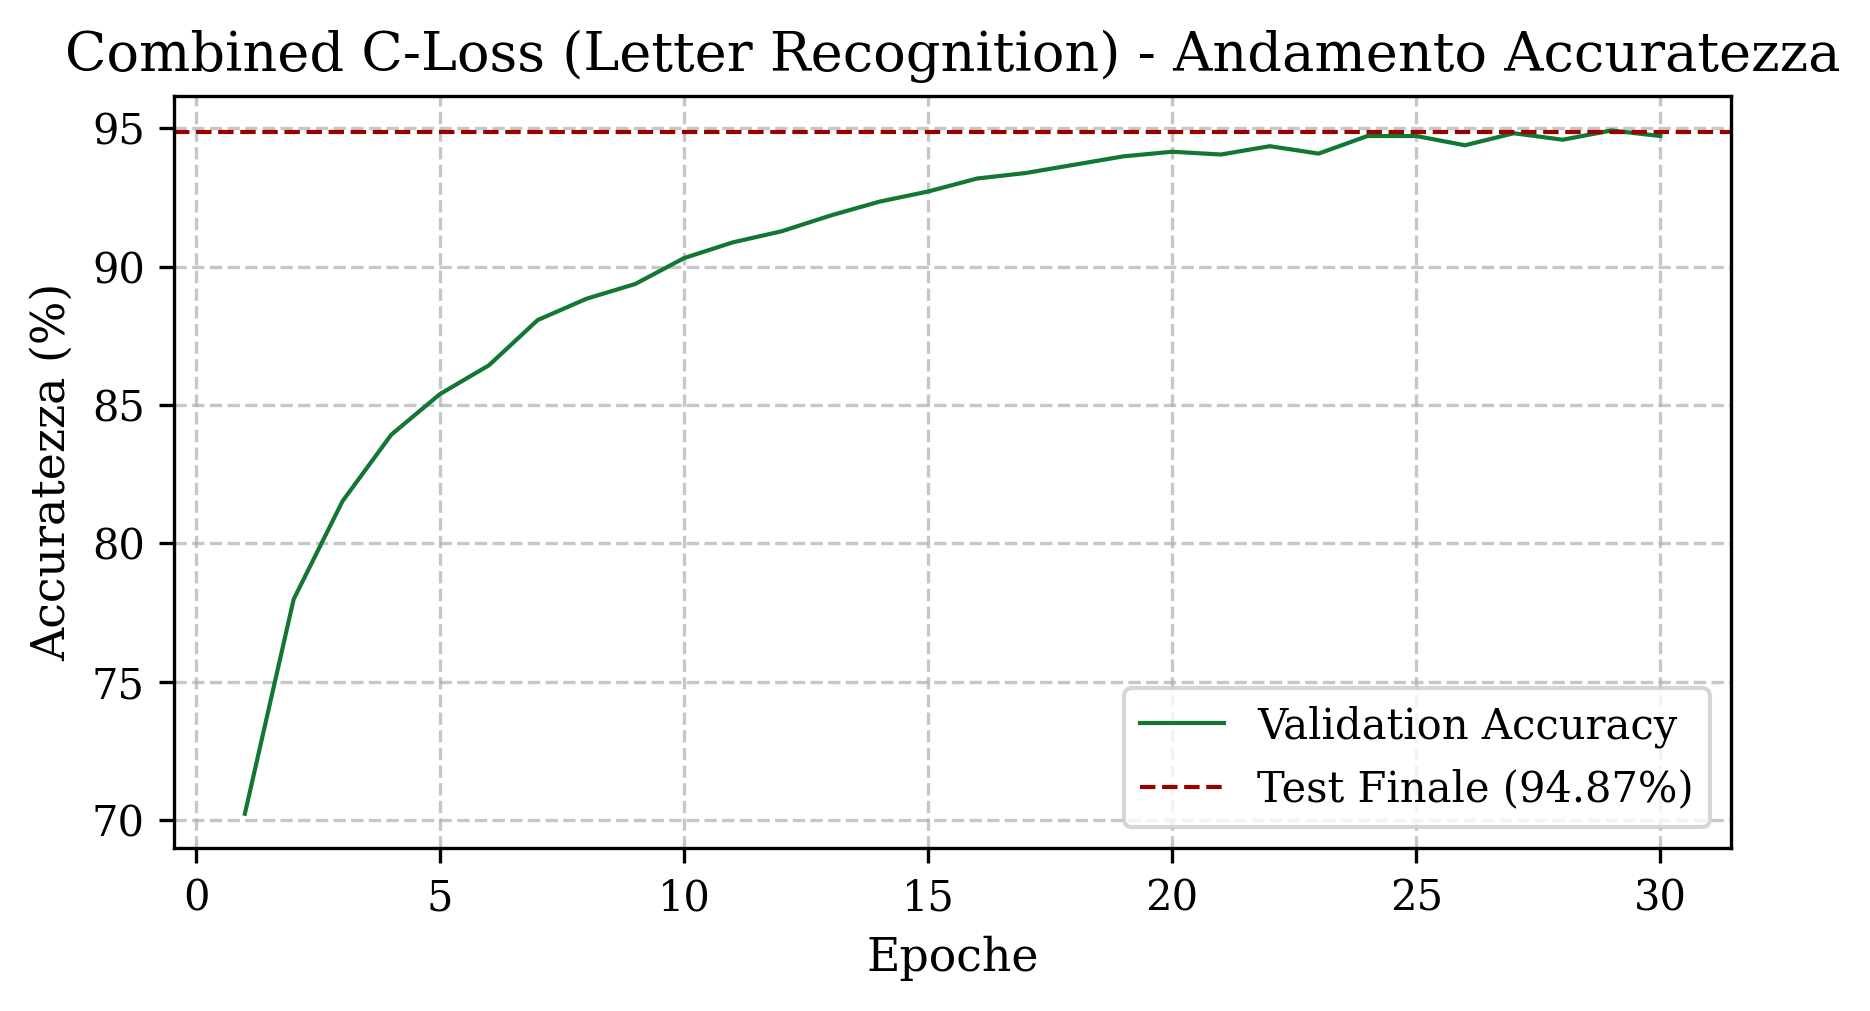

[*] Grafico salvato: plots\2026-05-04_19-53-30_Combined_C-Loss_(Letter_Recognition)_GDV.pdf


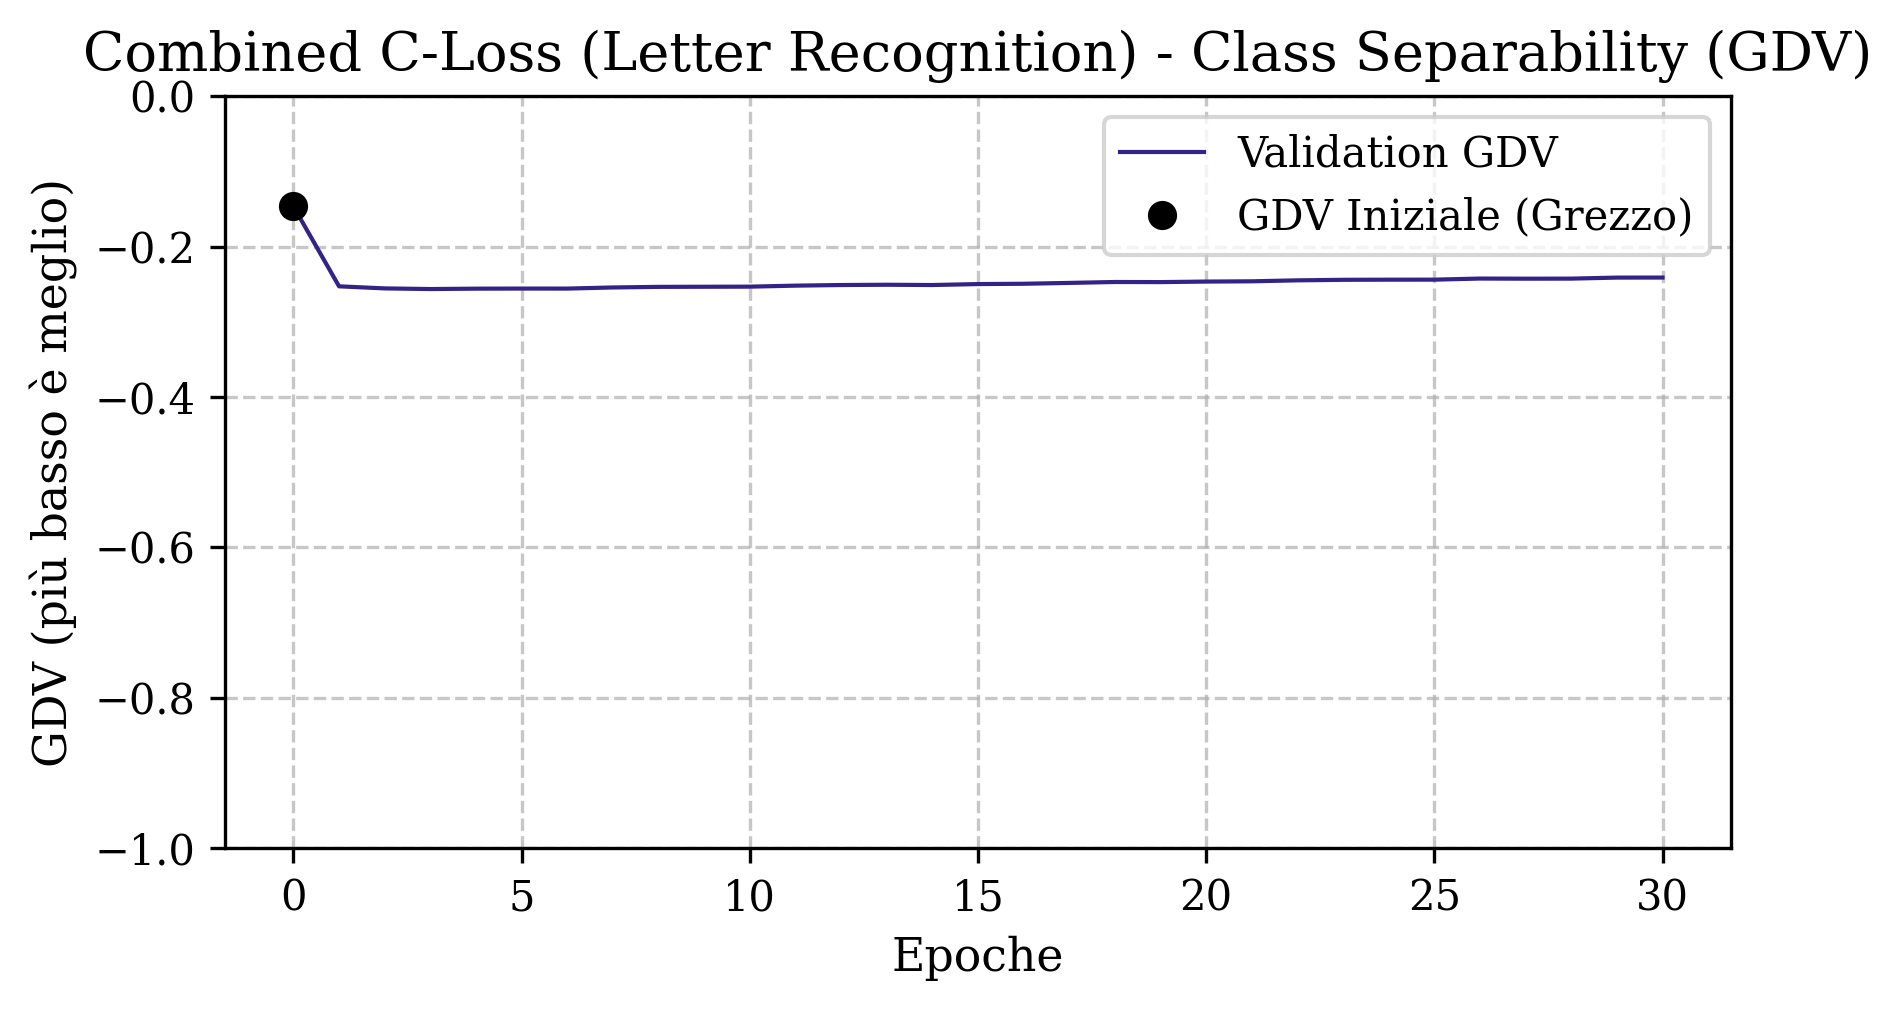

In [ ]:
# === ESPERIMENTO 3: Combined C-Loss ===
print(f"\nAvvio Addestramento: Combined C-Loss su {DATASET_NAME} (Hold-Out)")

torch.manual_seed(42)
model_polyloss = MLP(input_size=16, num_classes=num_classes).to(device)
criterion_polyloss = CombinedCLoss()
optimizer_polyloss = optim.Adam(model_polyloss.parameters(), lr=0.001)

history_poly, best_epoch_poly = train_model(
    model=model_polyloss, 
    criterion=criterion_polyloss, 
    optimizer=optimizer_polyloss, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    device=device,
    num_epochs=500, 
    layer_for_gdv=model_polyloss.relu2
)

test_acc_poly = evaluate_model(model_polyloss, test_loader, device)
history_poly['test_acc'] = test_acc_poly
print(f"Accuratezza Test Finale: {test_acc_poly:.2f}%")

# MLOps: Salvataggio log in JSON e generazione Grafici PDF
utils.salva_storico_json(history_poly, f"HoldOut_CombinedLoss_{DATASET_NAME_SAFE}", directory="logs")
plot_training_history(history_poly, f"Combined C-Loss ({DATASET_NAME})", GDV_INIZIALE, save_dir="plots")

In [ ]:
import numpy as np
import torch
import random
import os
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

# --- FUNZIONE SCUDO PER LA RIPRODUCIBILITÀ ---
def imposta_seed(seed=42):
    """Fissa tutti i generatori di numeri casuali per garantire riproducibilità."""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# === ESPERIMENTO K-FOLD CON GDV E SEED ROLLING ===
def run_kfold_experiment(loss_fn, model_name, X, y, k=10, epochs=200):
    print(f"\n=== AVVIO {k}-FOLD CV: {model_name} ===")
    
    # Fissiamo il seed globale per garantire che la divisione in fold sia identica per ogni Loss
    imposta_seed(42)
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    
    fold_accs = []
    fold_gdvs = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        print(f"\n--- Fold {fold+1}/{k} ---")
        
        # --- SEED ROLLING: La garanzia dell'equità strutturale ---
        # Il Fold N partirà sempre dalla stessa configurazione sinaptica, per qualsiasi Loss
        seed_corrente = 42 + fold
        imposta_seed(seed_corrente)
        # ---------------------------------------------------------
        
        # 1. Split corretto
        X_tr, X_va = X[train_idx], X[val_idx]
        y_tr, y_va = y[train_idx], y[val_idx]
        
        # 2. Scaling corretto (No Data Leakage!)
        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_tr)
        X_va_scaled = scaler.transform(X_va)
        
        # 3. Dataloaders
        tr_loader = create_dataloader(X_tr_scaled, y_tr, batch_size=64, shuffle=True)
        va_loader = create_dataloader(X_va_scaled, y_va, batch_size=64, shuffle=False)
        
        # 4. Modello pulito (Inizializzato ORA con il seed_corrente)
        input_dim = X_tensor.shape[1] 
        model = MLP(input_size=input_dim, num_classes=num_classes).to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        
        # 5. Addestramento
        history, best_ep = train_model(
            model=model, criterion=loss_fn, optimizer=optimizer,
            train_loader=tr_loader, val_loader=va_loader, device=device,
            num_epochs=epochs, layer_for_gdv=model.relu2 # Assicurati che model.relu2 sia corretto per la tua architettura
        )
        
        # 6. Registriamo i risultati (dal modello ripristinato al Best Checkpoint)
        acc = evaluate_model(model, va_loader, device)
        fold_accs.append(acc)
        
        # Prendiamo il GDV corrispondente all'epoca migliore salvata
        best_gdv = history['val_gdv'][best_ep - 1] if history['val_gdv'] else 0.0
        fold_gdvs.append(best_gdv)
        
    return fold_accs, fold_gdvs

# ... [Assumendo che la funzione run_kfold_experiment sia già definita come l'avevamo scritta] ...

print(f"\n=== ESECUZIONE 10-FOLD CV SU {DATASET_NAME} ===")

# Esecuzione per tutti e 3 i modelli
acc_ce, gdv_ce = run_kfold_experiment(nn.CrossEntropyLoss(), "Cross-Entropy", X_raw, y_raw)
acc_poly, gdv_poly = run_kfold_experiment(PolyLoss(epsilon=2.0), "PolyLoss", X_raw, y_raw)
acc_closs, gdv_closs = run_kfold_experiment(CombinedCLoss(sigma=0.5, gamma=0.5), "Combined C-Loss", X_raw, y_raw)

# MLOps: Salviamo i risultati grezzi del K-Fold in JSON!
kfold_results = {
    "dataset": DATASET_NAME,
    "folds": 10,
    "Cross-Entropy": {"acc": acc_ce, "gdv": gdv_ce},
    "PolyLoss": {"acc": acc_poly, "gdv": gdv_poly},
    "Combined C-Loss": {"acc": acc_closs, "gdv": gdv_closs}
}
utils.salva_storico_json(kfold_results, f"KFold_Results_{DATASET_NAME_SAFE}", directory="logs")

print("\n" + "="*50)
print("--- RIEPILOGO FINALE K-FOLD (Accuratezza Media) ---")
print(f"1. Cross-Entropy: {np.mean(acc_ce):.2f}% (± {np.std(acc_ce):.2f}%)")
print(f"2. PolyLoss:      {np.mean(acc_poly):.2f}% (± {np.std(acc_poly):.2f}%)")
print(f"3. C-Loss:        {np.mean(acc_closs):.2f}% (± {np.std(acc_closs):.2f}%)")



=== ESECUZIONE 10-FOLD CV SU Letter Recognition ===

=== AVVIO 10-FOLD CV: Cross-Entropy ===

--- Fold 1/10 ---
Epoca 01/30 | Train Loss: 1.6495 | Val Loss: 0.9053 | Val Acc: 74.60% | Val GDV: -0.2562
Epoca 05/30 | Train Loss: 0.4279 | Val Loss: 0.3850 | Val Acc: 88.50% | Val GDV: -0.2548
Epoca 10/30 | Train Loss: 0.2370 | Val Loss: 0.2405 | Val Acc: 93.15% | Val GDV: -0.2519
Epoca 15/30 | Train Loss: 0.1585 | Val Loss: 0.1753 | Val Acc: 94.85% | Val GDV: -0.2485
Epoca 20/30 | Train Loss: 0.1139 | Val Loss: 0.1607 | Val Acc: 94.90% | Val GDV: -0.2446
Epoca 25/30 | Train Loss: 0.0862 | Val Loss: 0.1418 | Val Acc: 95.00% | Val GDV: -0.2399
Epoca 30/30 | Train Loss: 0.0690 | Val Loss: 0.1194 | Val Acc: 95.90% | Val GDV: -0.2373

> Training completato in 17.14s.
> Ripristino pesi dell'epoca 30 (Miglior Val Loss: 0.1194)

--- Fold 2/10 ---
Epoca 01/30 | Train Loss: 1.6599 | Val Loss: 0.9331 | Val Acc: 73.85% | Val GDV: -0.2670
Epoca 05/30 | Train Loss: 0.3967 | Val Loss: 0.3924 | Val Acc: 

[*] Grafico K-Fold salvato per la tesi: plots\2026-05-04_20-05-37_KFold_Letter_Recognition_Acc.pdf


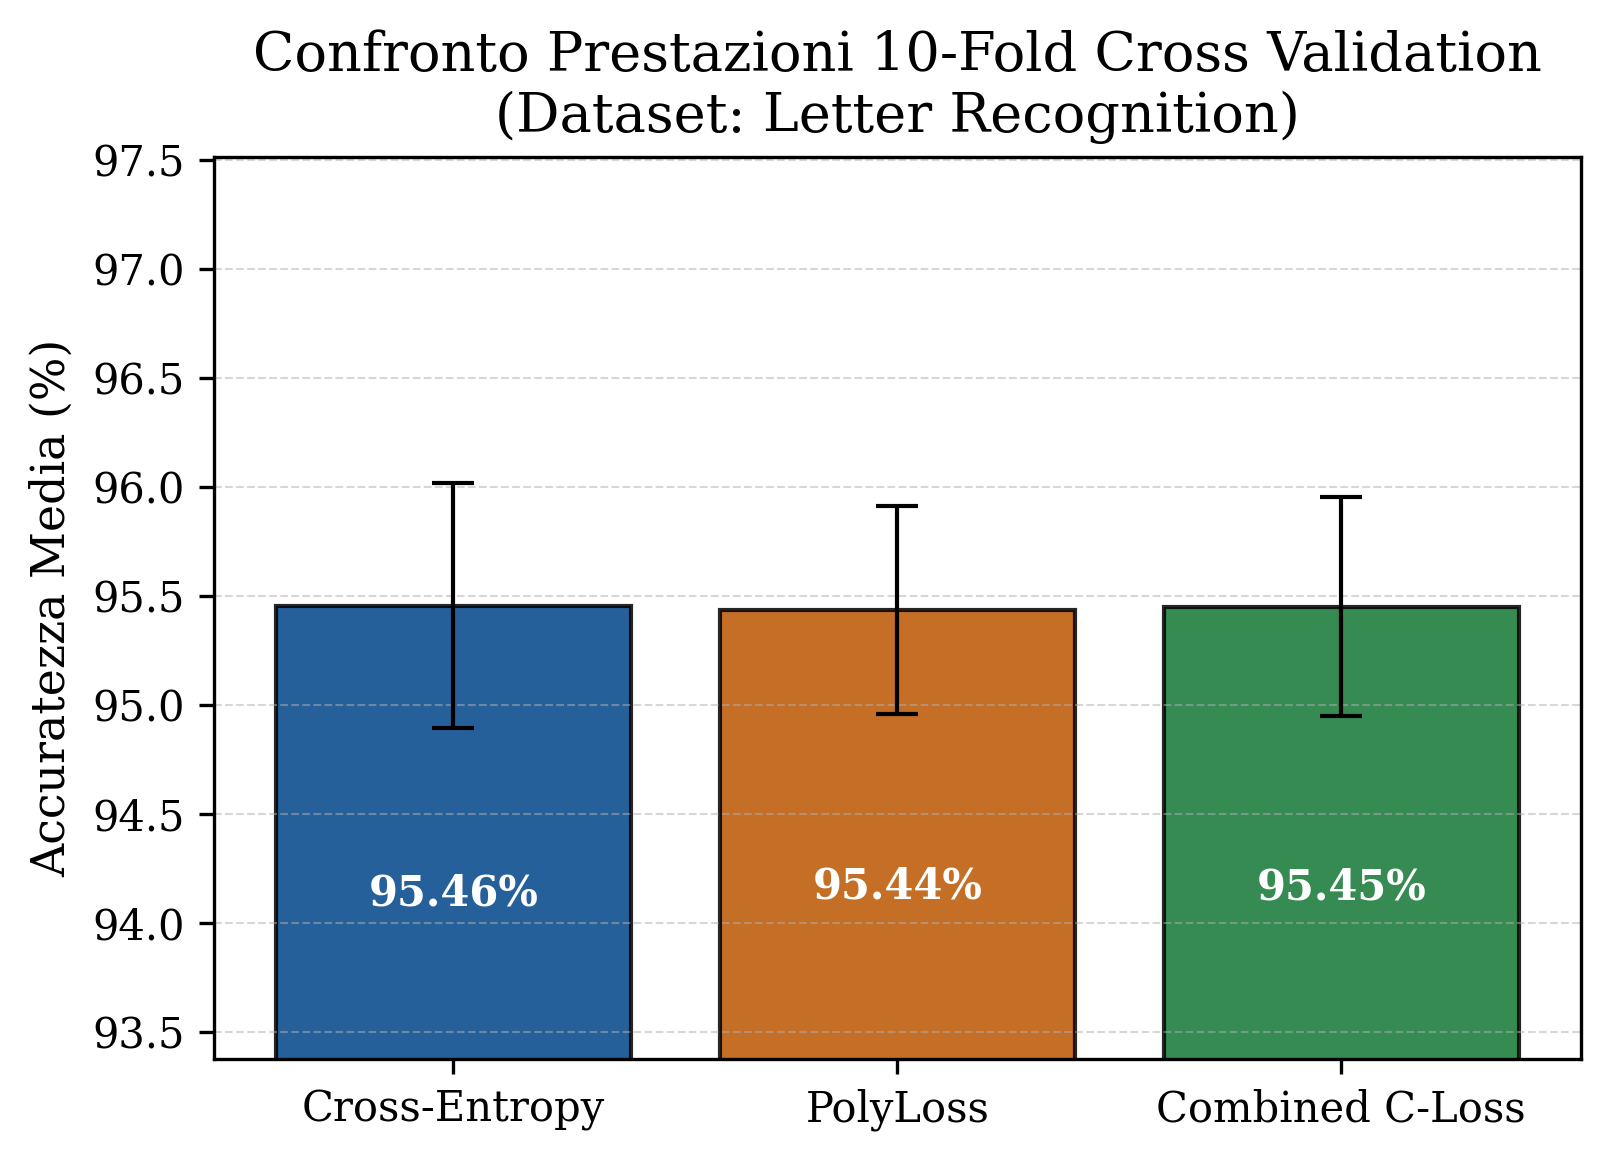

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import os
from datetime import datetime

# ==========================================
# CONFIGURAZIONE GLOBALE PER STAMPA TESI 
# ==========================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'lines.linewidth': 1.0,
    'figure.dpi': 300,
    'grid.linewidth': 0.5,
    'grid.alpha': 0.5
})

# ==========================================
# ESECUZIONE GRAFICO 10-FOLD
# ==========================================
fig, ax1 = plt.subplots(figsize=(5.5, 4.0))

modelli = ['Cross-Entropy', 'PolyLoss', 'Combined C-Loss']
medie_acc = [np.mean(acc_ce), np.mean(acc_poly), np.mean(acc_closs)]
std_acc = [np.std(acc_ce), np.std(acc_poly), np.std(acc_closs)]

# Colori ad alto contrasto per la stampa
colori = ['#004488', '#BB5500', '#117733']

# Spessori dei bordi e delle error bars impostati a 1.0
barre = ax1.bar(modelli, medie_acc, yerr=std_acc, capsize=5, 
                color=colori, alpha=0.85, edgecolor='black', linewidth=1.0,
                error_kw={'elinewidth': 1.0, 'capthick': 1.0})

# Adatta lo zoom in base ai dati reali lasciando margine
min_acc = min(medie_acc) - max(std_acc) - 1.5
max_acc = max(medie_acc) + max(std_acc) + 1.5
ax1.set_ylim(min_acc, max_acc)

ax1.set_ylabel('Accuratezza Media (%)')
ax1.set_title(f'Confronto Prestazioni 10-Fold Cross Validation\n(Dataset: {DATASET_NAME})')

# Inserimento dinamico delle percentuali all'interno delle barre
for i, (barra, media) in enumerate(zip(barre, medie_acc)):
    altezza = barra.get_height()
    base_error_bar = altezza - std_acc[i]
    y_text = min_acc + (base_error_bar - min_acc) / 2
    
    ax1.text(barra.get_x() + barra.get_width()/2., y_text, 
             f'{media:.2f}%', ha='center', va='center', 
             color='white', fontweight='bold', fontsize=10)

plt.grid(axis='y', linestyle='--')
plt.tight_layout()

# ==========================================
# SALVATAGGIO AUTOMATICO (MLOps)
# ==========================================
save_dir = "plots"
os.makedirs(save_dir, exist_ok=True)
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
filename_pdf = os.path.join(save_dir, f"{timestamp}_KFold_{DATASET_NAME_SAFE}_Acc.pdf")

plt.savefig(filename_pdf, format='pdf', bbox_inches='tight')
print(f"[*] Grafico K-Fold salvato per la tesi: {filename_pdf}")

plt.show()